In [1]:
#Imports Iniciales

#!pip install optuna

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import optuna
from optuna.samplers import TPESampler
from sklearn.svm import SVC
from sklearn.base import clone

In [2]:
# Read CSV file into a DataFrame
df_metadata = pd.read_csv('SraRunTable.csv')

df_metadata["disease_status"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(Patient|Control)", expand=False)
    .str.lower()
)

df_metadata["disease_status"] = df_metadata["disease_status"].map({
    "control": 0,
    "patient": 1
})

df_metadata["pair_id"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

df_metadata = df_metadata[["Run", "env_medium", "disease_status","pair_id"]]

df_metadata

,Run,env_medium,disease_status,pair_id
0,SRR32936395,Unstimulated saliva,1,17
1,SRR32936396,Unstimulated saliva,0,16
2,SRR32936397,Unstimulated saliva,1,3
3,SRR32936398,Unstimulated saliva,1,16
4,SRR32936408,Unstimulated saliva,1,2
...,...,...,...,...
247,SRR32938727,Supragingival swab,0,6
248,SRR32938728,Supragingival swab,1,6
249,SRR32938729,Supragingival swab,0,5
250,SRR32938733,Supragingival swab,1,4


In [3]:
df_asv = pd.read_csv('asv_table.tsv', sep = '\t', header=1)
df_asvt = df_asv.transpose()
new_header = df_asvt.iloc[0] 
df_asvt = df_asvt[1:] 
df_asvt.columns = new_header
df_asvt.reset_index(level=0, inplace=True, names=["Run"]) 
df_asvt.head()

#OTU ID,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,ad98578086fac11d2c8d482bac525d19,a094de4e58b9f291cdea1600e53ae871,518528979dc71666ec2bba322b9e806b,dec2a6a67a2a8cb475b16c04cd60c712,30a3a61dfd94eef22b368c4e078bcdf2,19322f53614269ad24c1b6e83d85b1a8,8d451bdf92f1a3f59016162bd25ddb2b,234ba3e9c68c5efdb496a08c06eb4fd1,580a3724eadd91834f6b885e8132c4d3,e8035cd0cf8992d4de5c688f1923022a
0,SRR32936402,9477.0,9235.0,8983.0,8878.0,7642.0,7406.0,5917.0,4881.0,4300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,0.0,945.0,9364.0,0.0,0.0,782.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,0.0,811.0,7265.0,11794.0,4946.0,0.0,574.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,0.0,7772.0,19553.0,5817.0,11248.0,0.0,408.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,0.0,6106.0,26832.0,6933.0,17034.0,0.0,2117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


ASVs con prevalencia ≥ 5%: 3145
ASVs totales: 8574
Porcentaje conservado: 36.68%


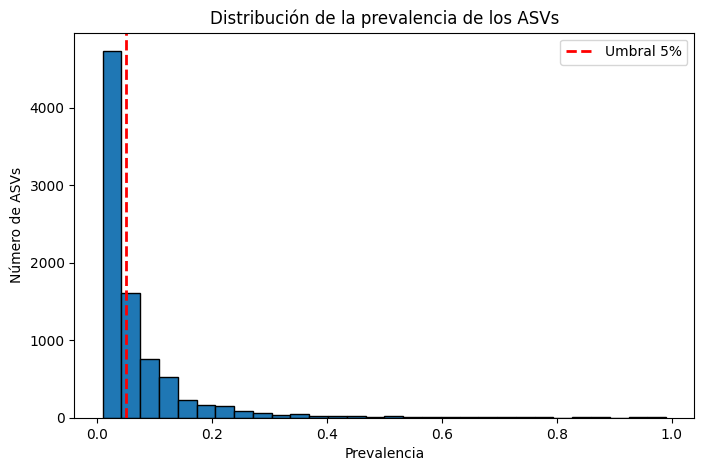

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Quedarse solo con las columnas de ASVs
asv_counts = df_asvt.drop(columns=["Run"])

# Prevalencia de cada ASV (fracción de muestras donde el conteo > 0)
prevalence = (asv_counts > 0).mean(axis=0)

# Número de ASVs que superan el 5%
n_asvs = (prevalence >= 0.05).sum()

print(f"ASVs con prevalencia ≥ 5%: {n_asvs}")
print(f"ASVs totales: {asv_counts.shape[1]}")
print(f"Porcentaje conservado: {100*n_asvs/asv_counts.shape[1]:.2f}%")

# Histograma de prevalencias
plt.figure(figsize=(8,5))
plt.hist(prevalence, bins=30, edgecolor="black")
plt.axvline(0.05, color="red", linestyle="--", linewidth=2,
            label="Umbral 5%")
plt.xlabel("Prevalencia")
plt.ylabel("Número de ASVs")
plt.title("Distribución de la prevalencia de los ASVs")
plt.legend()
plt.show()

In [5]:
# Seleccionar ASVs con prevalencia ≥ 5%
asv_counts_filtered = asv_counts.loc[:, prevalence >= 0.05]

# Comprobar resultados
print(f"ASVs después del filtrado: {asv_counts_filtered.shape[1]}")
print(f"ASVs eliminados: {asv_counts.shape[1] - asv_counts_filtered.shape[1]}")
print(f"Porcentaje conservado: {100*asv_counts_filtered.shape[1]/asv_counts.shape[1]:.2f}%")

# Si quieres volver a incluir la columna Run:
df_asvt_filtered = pd.concat([df_asvt["Run"], asv_counts_filtered], axis=1)
df_asvt_filtered.head()

ASVs después del filtrado: 3145
ASVs eliminados: 5429
Porcentaje conservado: 36.68%


,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,75577959de76c557eacbaa5e0a32ac1e,e0d558bfbfc50c29e78e09bf68c42c97,b61d71fc548f3849fd7dbe9e864b8ef0,ddeba385378bcfa1431be81037b53164,c7fd85a7c0324618d43324ffe588f141,c63d3c23053069365a401f575e30702f,865347dd799128cd797085e22752a360,de404875321aeb8fd9494f3dc52410e9,5b5ac7f6616efd791731856d7faa93a1,154f1e3953fb473362ca70d3c47d6ccb
0,SRR32936402,9477.0,9235.0,8983.0,8878.0,7642.0,7406.0,5917.0,4881.0,4300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,0.0,945.0,9364.0,0.0,0.0,782.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,0.0,811.0,7265.0,11794.0,4946.0,0.0,574.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,0.0,7772.0,19553.0,5817.0,11248.0,0.0,408.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,0.0,6106.0,26832.0,6933.0,17034.0,0.0,2117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#CLR transform

runs = df_asvt_filtered["Run"]

df_asvtclr = df_asvt_filtered.drop(columns="Run").astype(float)

df_asvtclr = df_asvtclr + 1

gm = np.exp(np.log(df_asvtclr).mean(axis=1))

df_asvtclr = np.log(df_asvtclr.div(gm, axis=0))

df_asvtclr.insert(0, "Run", runs)

df_asvtclr.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,75577959de76c557eacbaa5e0a32ac1e,e0d558bfbfc50c29e78e09bf68c42c97,b61d71fc548f3849fd7dbe9e864b8ef0,ddeba385378bcfa1431be81037b53164,c7fd85a7c0324618d43324ffe588f141,c63d3c23053069365a401f575e30702f,865347dd799128cd797085e22752a360,de404875321aeb8fd9494f3dc52410e9,5b5ac7f6616efd791731856d7faa93a1,154f1e3953fb473362ca70d3c47d6ccb
0,SRR32936402,8.749381,8.723516,8.695852,8.684096,8.534197,8.502833,8.278406,8.085962,7.959255,...,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348
1,SRR32936389,-0.603674,7.020945,-0.603674,-0.603674,6.248568,8.541060,-0.603674,-0.603674,6.059458,...,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674
2,SRR32938709,-0.374212,5.085373,-0.374212,6.325288,8.516749,9.001219,8.132324,-0.374212,5.980158,...,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212
3,SRR32936396,9.028948,5.447233,-0.378767,8.579645,9.502168,8.289945,8.949268,-0.378767,5.634948,...,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767
4,SRR32936412,9.309717,6.977578,-0.464914,8.252277,9.732473,8.379278,9.278111,-0.464914,7.193313,...,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914


In [7]:
#merge de ambas columnas
mg = pd.merge(df_asvtclr, df_metadata, on="Run", how="left")
mg

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,ddeba385378bcfa1431be81037b53164,c7fd85a7c0324618d43324ffe588f141,c63d3c23053069365a401f575e30702f,865347dd799128cd797085e22752a360,de404875321aeb8fd9494f3dc52410e9,5b5ac7f6616efd791731856d7faa93a1,154f1e3953fb473362ca70d3c47d6ccb,env_medium,disease_status,pair_id
0,SRR32936402,8.749381,8.723516,8.695852,8.684096,8.534197,8.502833,8.278406,8.085962,7.959255,...,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,Unstimulated saliva,1,14
1,SRR32936389,-0.603674,7.020945,-0.603674,-0.603674,6.248568,8.541060,-0.603674,-0.603674,6.059458,...,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,Unstimulated saliva,1,20
2,SRR32938709,-0.374212,5.085373,-0.374212,6.325288,8.516749,9.001219,8.132324,-0.374212,5.980158,...,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,Supragingival swab,1,15
3,SRR32936396,9.028948,5.447233,-0.378767,8.579645,9.502168,8.289945,8.949268,-0.378767,5.634948,...,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,Unstimulated saliva,0,16
4,SRR32936412,9.309717,6.977578,-0.464914,8.252277,9.732473,8.379278,9.278111,-0.464914,7.193313,...,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,Unstimulated saliva,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,SRR32936397,8.455451,6.436212,-0.542933,6.618689,8.605531,8.965658,8.868468,-0.542933,6.454662,...,-0.542933,-0.542933,-0.542933,-0.542933,-0.542933,-0.542933,1.759652,Unstimulated saliva,1,3
97,SRR32938719,-0.467491,6.711817,-0.467491,4.860385,8.957396,9.973805,7.539543,-0.467491,6.195642,...,-0.467491,0.225657,-0.467491,-0.467491,-0.467491,0.918804,-0.467491,Supragingival swab,0,10
98,SRR32936399,6.911111,7.268421,8.497932,-0.450264,8.979693,8.264960,8.577834,-0.450264,2.685230,...,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,Unstimulated saliva,0,15
99,SRR32938700,-0.440393,1.756831,-0.440393,-0.440393,6.823637,10.774018,5.977971,-0.440393,4.897145,...,-0.440393,2.044513,-0.440393,-0.440393,-0.440393,-0.440393,-0.440393,Supragingival swab,1,19


In [8]:
#ohe
df_analisis_ohe = pd.get_dummies(mg, columns= ['env_medium'], drop_first=False)
df_analisis_ohe.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,c7fd85a7c0324618d43324ffe588f141,c63d3c23053069365a401f575e30702f,865347dd799128cd797085e22752a360,de404875321aeb8fd9494f3dc52410e9,5b5ac7f6616efd791731856d7faa93a1,154f1e3953fb473362ca70d3c47d6ccb,disease_status,pair_id,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,SRR32936402,8.749381,8.723516,8.695852,8.684096,8.534197,8.502833,8.278406,8.085962,7.959255,...,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,1,14,False,True
1,SRR32936389,-0.603674,7.020945,-0.603674,-0.603674,6.248568,8.541060,-0.603674,-0.603674,6.059458,...,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,1,20,False,True
2,SRR32938709,-0.374212,5.085373,-0.374212,6.325288,8.516749,9.001219,8.132324,-0.374212,5.980158,...,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,1,15,True,False
3,SRR32936396,9.028948,5.447233,-0.378767,8.579645,9.502168,8.289945,8.949268,-0.378767,5.634948,...,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,0,16,False,True
4,SRR32936412,9.309717,6.977578,-0.464914,8.252277,9.732473,8.379278,9.278111,-0.464914,7.193313,...,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,0,9,False,True


In [9]:
# Variable objetivo
y = df_analisis_ohe["disease_status"]

# Grupos para los folds
groups = df_analisis_ohe["pair_id"]

# Variables predictoras
X = df_analisis_ohe.drop(columns=[
    "Run",
    "disease_status",
    "pair_id"
])
X

,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,...,b61d71fc548f3849fd7dbe9e864b8ef0,ddeba385378bcfa1431be81037b53164,c7fd85a7c0324618d43324ffe588f141,c63d3c23053069365a401f575e30702f,865347dd799128cd797085e22752a360,de404875321aeb8fd9494f3dc52410e9,5b5ac7f6616efd791731856d7faa93a1,154f1e3953fb473362ca70d3c47d6ccb,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,8.749381,8.723516,8.695852,8.684096,8.534197,8.502833,8.278406,8.085962,7.959255,7.845619,...,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,-0.407348,False,True
1,-0.603674,7.020945,-0.603674,-0.603674,6.248568,8.541060,-0.603674,-0.603674,6.059458,4.502271,...,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,-0.603674,False,True
2,-0.374212,5.085373,-0.374212,6.325288,8.516749,9.001219,8.132324,-0.374212,5.980158,7.160016,...,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,-0.374212,True,False
3,9.028948,5.447233,-0.378767,8.579645,9.502168,8.289945,8.949268,-0.378767,5.634948,7.101097,...,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,-0.378767,False,True
4,9.309717,6.977578,-0.464914,8.252277,9.732473,8.379278,9.278111,-0.464914,7.193313,7.301503,...,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,-0.464914,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,8.455451,6.436212,-0.542933,6.618689,8.605531,8.965658,8.868468,-0.542933,6.454662,6.909469,...,-0.542933,-0.542933,-0.542933,-0.542933,-0.542933,-0.542933,-0.542933,1.759652,False,True
97,-0.467491,6.711817,-0.467491,4.860385,8.957396,9.973805,7.539543,-0.467491,6.195642,7.304420,...,-0.467491,-0.467491,0.225657,-0.467491,-0.467491,-0.467491,0.918804,-0.467491,True,False
98,6.911111,7.268421,8.497932,-0.450264,8.979693,8.264960,8.577834,-0.450264,2.685230,7.012525,...,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,-0.450264,False,True
99,-0.440393,1.756831,-0.440393,-0.440393,6.823637,10.774018,5.977971,-0.440393,4.897145,4.695405,...,-0.440393,-0.440393,2.044513,-0.440393,-0.440393,-0.440393,-0.440393,-0.440393,True,False


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, balanced_accuracy_score


# Silenciar los mensajes de log informativos de Optuna para no saturar la pantalla
optuna.logging.set_verbosity(optuna.logging.WARNING)

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

best_models = []
scores = []
results = []

# Validación cruzada externa
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), 1):
    print(f"\n--- Procesando Fold {fold} ---")
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    def objective(trial):

        params = {
            'C': trial.suggest_float('C', 1e-2, 1e3, log=True),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
        
        gamma_type = trial.suggest_categorical('gamma_type', ['scale', 'auto', 'custom'])
        if gamma_type == 'custom':
            params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
        else:
            params['gamma'] = gamma_type

        inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = []

        for in_train_idx, in_val_idx in inner_cv.split(X_train, y_train, groups_train):
            X_in_train, X_val = X_train.iloc[in_train_idx], X_train.iloc[in_val_idx]
            y_in_train, y_val = y_train.iloc[in_train_idx], y_train.iloc[in_val_idx]

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svc", SVC(**params))
            ])

            model.fit(X_in_train, y_in_train)

            scores = model.decision_function(X_val)

            cv_scores.append(
                roc_auc_score(y_val, scores)
            )

        return np.mean(cv_scores)

    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=50)

    best_params = study.best_params
    
    if best_params['gamma_type'] == 'custom':
        best_params['gamma'] = best_params.pop('gamma')
    else:
        best_params['gamma'] = best_params['gamma_type']
    del best_params['gamma_type']

    print(f"Mejores hiperparámetros: {best_params}")

    best_svc = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(**best_params))
    ])
    best_svc.fit(X_train, y_train)

    test_preds = best_svc.predict(X_test)

    test_scores = best_svc.decision_function(X_test)

    fold_auc = roc_auc_score(
        y_test,
        test_scores
    )

    fold_f1_weighted = f1_score(
        y_test, 
        test_preds, 
        average='weighted'
    )
    
    fold_f1_macro = f1_score(
        y_test, 
        test_preds, 
        average='macro'
    )
    
    fold_bal_acc = balanced_accuracy_score(
        y_test, 
        test_preds
    )
    
    results.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "f1_weighted": fold_f1_weighted,
        "f1_macro": fold_f1_macro,
        "balanced_accuracy": fold_bal_acc,
        "best_params": best_params
    })
    
    scores.append(fold_f1_weighted)
    best_models.append(best_svc)
    
    print(f"ROC-AUC      (Fold {fold}): {fold_auc:.4f}")
    print(f"F1 weighted  (Fold {fold}): {fold_f1_weighted:.4f}")
    print(f"F1 macro     (Fold {fold}): {fold_f1_macro:.4f}")
    print(f"Balanced Acc (Fold {fold}): {fold_bal_acc:.4f}")


--- Procesando Fold 1 ---
Mejores hiperparámetros: {'C': 142.2896221065922, 'class_weight': None, 'gamma': 0.00010815425103462295}
ROC-AUC      (Fold 1): 0.8409
F1 weighted  (Fold 1): 0.7801
F1 macro     (Fold 1): 0.7810
Balanced Acc (Fold 1): 0.7879

--- Procesando Fold 2 ---
Mejores hiperparámetros: {'C': 19.724802059818767, 'class_weight': 'balanced', 'gamma': 0.00010103440325667329}
ROC-AUC      (Fold 2): 0.8500
F1 weighted  (Fold 2): 0.6970
F1 macro     (Fold 2): 0.6970
Balanced Acc (Fold 2): 0.7000

--- Procesando Fold 3 ---
Mejores hiperparámetros: {'C': 8.63668520609288, 'class_weight': None, 'gamma': 0.00010109588612133654}
ROC-AUC      (Fold 3): 0.6700
F1 weighted  (Fold 3): 0.6491
F1 macro     (Fold 3): 0.6491
Balanced Acc (Fold 3): 0.6500

--- Procesando Fold 4 ---
Mejores hiperparámetros: {'C': 3.3313772021630093, 'class_weight': 'balanced', 'gamma': 0.00010257372409459876}
ROC-AUC      (Fold 4): 0.8625
F1 weighted  (Fold 4): 0.7196
F1 macro     (Fold 4): 0.7143
Balanced 

In [11]:
print(best_models)

[Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=142.2896221065922, gamma=0.00010815425103462295))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=19.724802059818767, class_weight='balanced',
                     gamma=0.00010103440325667329))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=8.63668520609288, gamma=0.00010109588612133654))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=3.3313772021630093, class_weight='balanced',
                     gamma=0.00010257372409459876))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=19.724802059818767, class_weight='balanced',
                     gamma=0.00010103440325667329))])]


In [12]:
#Comprobación de grupos
for train_idx, test_idx in outer_cv.split(X, y, groups):
    train_pairs = set(groups.iloc[train_idx])
    test_pairs = set(groups.iloc[test_idx])

    print(train_pairs.intersection(test_pairs))

set()
set()
set()
set()
set()


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_score,
    recall_score
)



final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=19.724802059818767,
        gamma=0.00010103440325667329,
        class_weight="balanced"
    ))
])

In [14]:
# Validación cruzada 
outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)




y_true_all = []
y_pred_all = []
y_score_all = []

fold_results = []


from sklearn.base import clone

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n--- Fold {fold} ---")

    # Crear modelo independiente
    model_fold = clone(final_model)


    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    # Entrenar
    model_fold.fit(
        X_train,
        y_train
    )


    # Predicción clase
    y_pred = model_fold.predict(
        X_test
    )


    # Score continuo para ROC
    y_score = model_fold.decision_function(
        X_test
    )


    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_score_all.extend(y_score)



    fold_auc = roc_auc_score(
        y_test,
        y_score
    )

    fold_bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    fold_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    fold_results.append({
        "fold": fold,
        "ROC-AUC": fold_auc,
        "Balanced Accuracy": fold_bal_acc,
        "F1 weighted": fold_f1
    })


    print(f"ROC-AUC: {fold_auc:.4f}")
    print(f"Balanced Accuracy: {fold_bal_acc:.4f}")
    print(f"F1 weighted: {fold_f1:.4f}")


--- Fold 1 ---
ROC-AUC: 0.8409
Balanced Accuracy: 0.8295
F1 weighted: 0.8254

--- Fold 2 ---
ROC-AUC: 0.8500
Balanced Accuracy: 0.7000
F1 weighted: 0.6970

--- Fold 3 ---
ROC-AUC: 0.6700
Balanced Accuracy: 0.6500
F1 weighted: 0.6491

--- Fold 4 ---
ROC-AUC: 0.8625
Balanced Accuracy: 0.7125
F1 weighted: 0.7196

--- Fold 5 ---
ROC-AUC: 0.5400
Balanced Accuracy: 0.6000
F1 weighted: 0.6000


In [15]:
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_score_all = np.array(y_score_all)


accuracy = accuracy_score(
    y_true_all,
    y_pred_all
)

balanced_acc = balanced_accuracy_score(
    y_true_all,
    y_pred_all
)

roc_auc = roc_auc_score(
    y_true_all,
    y_score_all
)

f1_macro = f1_score(
    y_true_all,
    y_pred_all,
    average="macro"
)

f1_weighted = f1_score(
    y_true_all,
    y_pred_all,
    average="weighted"
)

precision = precision_score(
    y_true_all,
    y_pred_all
)

recall = recall_score(
    y_true_all,
    y_pred_all
)


print(f"Accuracy:            {accuracy:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print(f"ROC-AUC:             {roc_auc:.4f}")
print(f"F1 macro:            {f1_macro:.4f}")
print(f"F1 weighted:         {f1_weighted:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")


print("\nClassification report:\n")

print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=[
            "Control",
            "Paciente"
        ]
    )
)


Accuracy:            0.7030
Balanced Accuracy:   0.7025
ROC-AUC:             0.7549
F1 macro:            0.7022
F1 weighted:         0.7024
Precision:           0.6909
Recall:              0.7451

Classification report:

              precision    recall  f1-score   support

     Control       0.72      0.66      0.69        50
    Paciente       0.69      0.75      0.72        51

    accuracy                           0.70       101
   macro avg       0.70      0.70      0.70       101
weighted avg       0.70      0.70      0.70       101



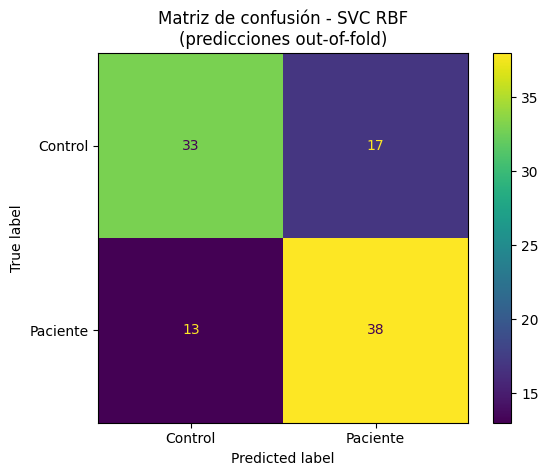

In [16]:
# Matriz de confusión


cm = confusion_matrix(
    y_true_all,
    y_pred_all
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Control",
        "Paciente"
    ]
)


disp.plot(
    values_format="d"
)

plt.title(
    "Matriz de confusión - SVC RBF\n(predicciones out-of-fold)"
)

plt.show()

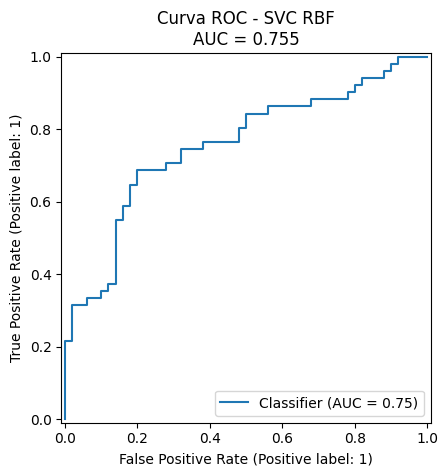

In [17]:
# Curva ROC

RocCurveDisplay.from_predictions(
    y_true_all,
    y_score_all
)

plt.title(
    f"Curva ROC - SVC RBF\nAUC = {roc_auc:.3f}"
)

plt.show()

In [18]:
# Tabla resumen de folds


fold_results = pd.DataFrame(
    fold_results
)

print("\nResultados por fold:")
display(fold_results)


print("\nMedia ± desviación estándar:")
display(
    fold_results.drop(columns="fold")
    .agg(["mean","std"])
)


Resultados por fold:


,fold,ROC-AUC,Balanced Accuracy,F1 weighted
0,1,0.840909,0.829545,0.825428
1,2,0.850000,0.700000,0.696970
2,3,0.670000,0.650000,0.649123
3,4,0.862500,0.712500,0.719577
4,5,0.540000,0.600000,0.600000



Media ± desviación estándar:


,ROC-AUC,Balanced Accuracy,F1 weighted
mean,0.752682,0.698409,0.698219
std,0.142640,0.085769,0.084701


In [19]:
#Interpretabilidad con SHAP

In [20]:
import warnings
warnings.filterwarnings("ignore")

import shap
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold


outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

shap_importances = []


for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n========== Fold {fold} ==========")


    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]


    model_fold = clone(final_model)

    model_fold.fit(
        X_train,
        y_train
    )

    background = shap.sample(
        X_train,
        100,
        random_state=42
    )
    
    
    def predict_function(X_input):
        return model_fold.decision_function(X_input)
    
    
    explainer = shap.KernelExplainer(
        predict_function,
        background
    )
    
    
    shap_values = explainer.shap_values(
        X_test,
        nsamples=100
    )

    importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X.columns
    )


    shap_importances.append(
        importance
    )


    print(f"Fold {fold} terminado")




shap_df = pd.concat(
    shap_importances,
    axis=1
)


shap_df.columns = [
    f"Fold_{i}"
    for i in range(1,6)
]


shap_df["Mean_SHAP"] = shap_df.mean(axis=1)

shap_df["Std_SHAP"] = shap_df.std(axis=1)


shap_df["CV_SHAP"] = (
    shap_df["Std_SHAP"] /
    shap_df["Mean_SHAP"]
)


shap_df = shap_df.sort_values(
    "Mean_SHAP",
    ascending=False
)


display(
    shap_df.head(20)
)


========== Fold 1 ==========


  0%|          | 0/23 [00:00<?, ?it/s]

Fold 1 terminado

========== Fold 2 ==========


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 2 terminado

========== Fold 3 ==========


...

  0%|          | 0/18 [00:00<?, ?it/s]

Fold 4 terminado

========== Fold 5 ==========


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 5 terminado


,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Mean_SHAP,Std_SHAP,CV_SHAP
6ab32bb12e11c38ad022554f6257beb2,0.000000,0.000000,0.000000,1.296555e+13,0.000000,2.593111e+12,5.186221e+12,2.000000
0c51710d28c254a306ff3c93f074e71f,0.000000,0.000000,0.000000,1.296555e+13,0.000000,2.593111e+12,5.186221e+12,2.000000
699c0c83dd19f1d75ff6347704b28a90,0.000000,0.000000,0.000000,1.296555e+13,0.000000,2.593111e+12,5.186221e+12,2.000000
50de620b6ec6f87267562cfb76dce959,0.000000,0.000000,0.000000,1.296555e+13,0.000000,2.593111e+12,5.186221e+12,2.000000
013703ef3e30a024ebc6ba0e41bb6321,0.000000,0.000000,0.000000,9.054664e-03,0.007111,3.233108e-03,4.007158e-03,1.239413
7555d934864fb3b45c3de8abdbc73e67,0.000000,0.000000,0.002527,0.000000e+00,0.011734,2.852301e-03,4.547490e-03,1.594323
75e7f15ceb840fdadd7478c3cf3a8307,0.000000,0.000000,0.000000,1.262620e-02,0.000000,2.525239e-03,5.050479e-03,2.000000
a8f4c26e2576e8f9e8f589f84d134389,0.000000,0.000000,0.000000,0.000000e+00,0.011303,2.260654e-03,4.521307e-03,2.000000
0116ada3921fb5b2ac1f8dd0cd392844,0.000000,0.011057,0.000000,0.000000e+00,0.000000,2.211341e-03,4.422683e-03,2.000000
958491ad7f5c4c3f1591e422a1189ce8,0.000000,0.000000,0.000000,1.094305e-02,0.000000,2.188611e-03,4.377222e-03,2.000000


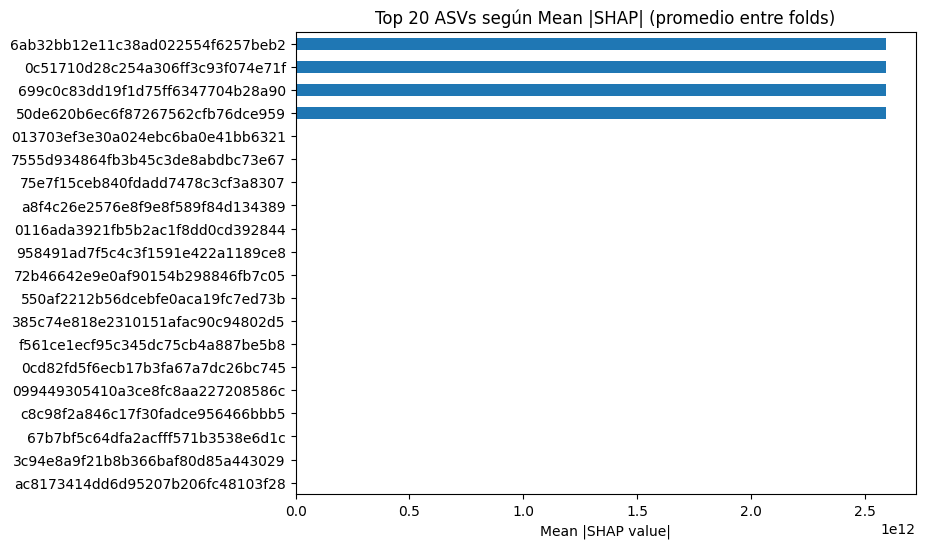

In [21]:
top_features = shap_df.head(20).index


plt.figure(figsize=(8,6))

shap_df.loc[top_features,"Mean_SHAP"].sort_values().plot(
    kind="barh"
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.title(
    "Top 20 ASVs según Mean |SHAP| (promedio entre folds)"
)

plt.show()

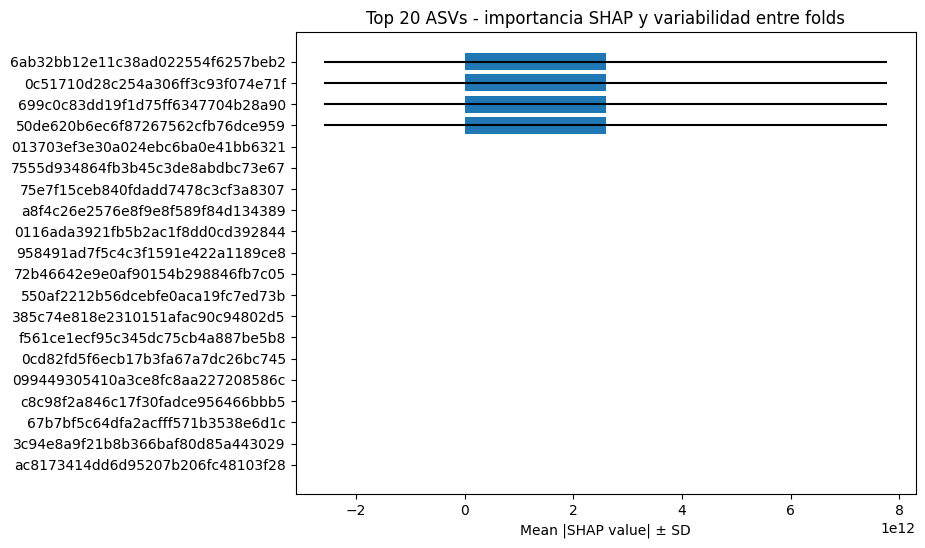

In [22]:
top = shap_df.head(20).sort_values("Mean_SHAP")

plt.figure(figsize=(8,6))

plt.barh(
    top.index,
    top["Mean_SHAP"],
    xerr=top["Std_SHAP"]
)

plt.xlabel(
    "Mean |SHAP value| ± SD"
)

plt.title(
    "Top 20 ASVs - importancia SHAP y variabilidad entre folds"
)

plt.show()